# Task 1 – Exploratory NLP Analysis of Severe Weather Narratives

This task focuses on exploring and analysing severe weather reports collected by the United States National Weather Service (NWS). The objective is to better understand weather event patterns, damage distributions, and the relationship between textual narratives and severe weather impacts using Natural Language Processing (NLP) techniques.

The analysis includes:
- data exploration and preprocessing,
- damage distribution analysis,
- weather event frequency analysis,
- and later, NLP methods such as text normalization and TF-IDF analysis.

*Note: The dataset contains severe weather reports collected by the United States National Weather Service (NWS). Most events are associated with US states and regions, making the analysis geographically focused on weather hazards across the United States.

## 1. Data Loading and Exploration

In this section, the datasets were loaded and merged using the common `id` column. Initial exploration was performed to better understand:
- the structure of the data,
- available variables,
- weather event categories,
- textual narratives,
- and damage values.

Missing values were also identified and handled appropriately before further analysis.

In [2]:
# Module imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk

In [3]:
nltk.download("popular", quiet=True)

True

In [4]:
# Load datasets

train = pd.read_csv("/Users/mirunabelulescu/Desktop/UNIGE/Year2/Semester2/Courses/2.ATML/2.NLP/Group_Project/data/train.csv")
additional_info = pd.read_csv("/Users/mirunabelulescu/Desktop/UNIGE/Year2/Semester2/Courses/2.ATML/2.NLP/Group_Project/data/additional_info.csv")

In [5]:
# Dataset shapes

print("Train shape:", train.shape)
print("Additional info shape:", additional_info.shape)

Train shape: (785162, 5)
Additional info shape: (785162, 4)


In [6]:
# First rows of train dataset

train.head()

,id,event_type,episode_narrative,event_narrative,damage
0,347570,Flash Flood,Tropical Storm Lee formed from a persistent lo...,The Dade County Emergency Management Director ...,10000.0
1,1054380,Marine Thunderstorm Wind,Scattered thunderstorms moved across portions ...,A wind gust to 36 knots was measured at the Mo...,0.0
2,317977,Thunderstorm Wind,"During the evening hours on July 19th, a sever...",Numerous trees and power lines were downed acr...,50000.0
3,509299,High Wind,An upper-level trough moved through southern C...,The Big Black Mountain mesonet recorded a peak...,0.0
4,1009291,Hail,A small cluster of thunderstorms developed nor...,Quarter size hail fell near Rural.,0.0


In [7]:
# First rows of additional info dataset

additional_info.head()

,id,begin_date_time,cz_timezone,state
0,347570,05-SEP-11 14:30:00,EST-5,GEORGIA
1,1054380,20-SEP-22 17:19:00,CST-6,LAKE MICHIGAN
2,317977,19-JUL-11 22:45:00,EST-5,KENTUCKY
3,509299,26-APR-14 01:00:00,PST-8,CALIFORNIA
4,1009291,12-APR-22 16:16:00,CST-6,WISCONSIN


In [8]:
# Merge datasets

df = train.merge(additional_info, on="id", how="left")

print("Merged dataset shape:", df.shape)

df.head()

Merged dataset shape: (785162, 8)


,id,event_type,episode_narrative,event_narrative,damage,begin_date_time,cz_timezone,state
0,347570,Flash Flood,Tropical Storm Lee formed from a persistent lo...,The Dade County Emergency Management Director ...,10000.0,05-SEP-11 14:30:00,EST-5,GEORGIA
1,1054380,Marine Thunderstorm Wind,Scattered thunderstorms moved across portions ...,A wind gust to 36 knots was measured at the Mo...,0.0,20-SEP-22 17:19:00,CST-6,LAKE MICHIGAN
2,317977,Thunderstorm Wind,"During the evening hours on July 19th, a sever...",Numerous trees and power lines were downed acr...,50000.0,19-JUL-11 22:45:00,EST-5,KENTUCKY
3,509299,High Wind,An upper-level trough moved through southern C...,The Big Black Mountain mesonet recorded a peak...,0.0,26-APR-14 01:00:00,PST-8,CALIFORNIA
4,1009291,Hail,A small cluster of thunderstorms developed nor...,Quarter size hail fell near Rural.,0.0,12-APR-22 16:16:00,CST-6,WISCONSIN


In [9]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785162 entries, 0 to 785161
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 785162 non-null  int64  
 1   event_type         785162 non-null  object 
 2   episode_narrative  697152 non-null  object 
 3   event_narrative    694988 non-null  object 
 4   damage             785162 non-null  float64
 5   begin_date_time    785162 non-null  object 
 6   cz_timezone        785162 non-null  object 
 7   state              785161 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 47.9+ MB


In [10]:
# Handle missing values

# Replace missing text narratives with empty strings
# This avoids errors during text analysis

df["episode_narrative"] = df["episode_narrative"].fillna("")
df["event_narrative"] = df["event_narrative"].fillna("")

# Replace missing state values with "Unknown"
# This keeps the categorical information consistent

df["state"] = df["state"].fillna("Unknown")

# Check if there are any remaining missing values

df.isnull().sum()

id                   0
event_type           0
episode_narrative    0
event_narrative      0
damage               0
begin_date_time      0
cz_timezone          0
state                0
dtype: int64

## 2. Analysis of Weather Events and Economic Damage

This section explores the relationship between severe weather events and their economic impact across the United States.

The analysis focuses on:
- financial damage distribution,
- weather event frequency,
- damage by event type,
- and geographic patterns across states and territories.

The goal is to identify important trends and patterns before applying NLP and machine learning techniques.

### 2.1 Financial Damage Analysis

This subsection examines the distribution and severity of financial damage caused by severe weather events.

In [11]:
# Damage statistics

df["damage"].describe()

count    7.851620e+05
mean     2.093722e+05
std      7.275036e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+03
max      9.400000e+08
Name: damage, dtype: float64

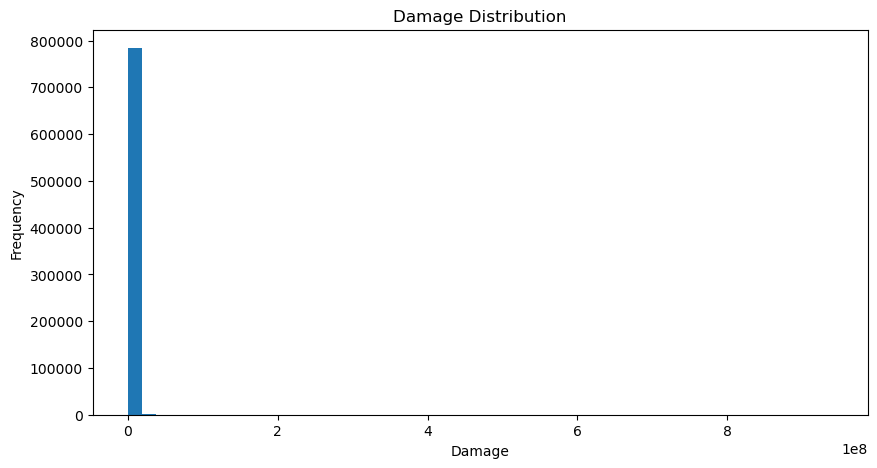

In [12]:
# Damage distribution

plt.figure(figsize=(10,5))

plt.hist(df["damage"], bins=50)

plt.title("Damage Distribution")
plt.xlabel("Damage")
plt.ylabel("Frequency")

plt.show()

**Interpretation of the Damage Distribution**

- The original damage distribution is extremely right-skewed, with most events concentrated near zero damage values.
- A very large number of weather events caused little or no reported economic damage.
- A small number of extreme events produced exceptionally high losses, creating strong outliers in the dataset.
- Because of these outliers, the histogram becomes highly compressed, making it difficult to clearly observe the variation among lower and moderate damage values.
- This distribution indicates that economic impacts are highly uneven across severe weather events.

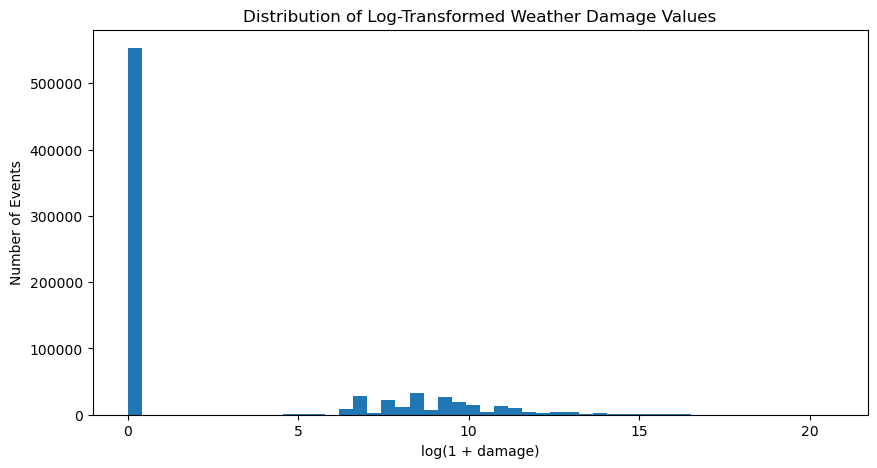

In [64]:
# Log-transformed distribution of all damage values

plt.figure(figsize=(10,5))

# Apply logarithmic transformation to damage values
log_damage = np.log1p(df["damage"])

# Plot histogram
plt.hist(log_damage, bins=50)

# Titles and labels
plt.title("Distribution of Log-Transformed Weather Damage Values")
plt.xlabel("log(1 + damage)")
plt.ylabel("Number of Events")

plt.show()

In [72]:
# Compare number of events and total financial damage

summary = pd.DataFrame({
    "Category": ["Zero-damage events", "Non-zero damage events"],
    "Number of Events": [
        (df["damage"] == 0).sum(),
        (df["damage"] > 0).sum()
    ],
    "Total Financial Damage": [
        df[df["damage"] == 0]["damage"].sum(),
        df[df["damage"] > 0]["damage"].sum()
    ]
})

summary

,Category,Number of Events,Total Financial Damage
0,Zero-damage events,553088,0.000000e+00
1,Non-zero damage events,232074,1.643911e+11


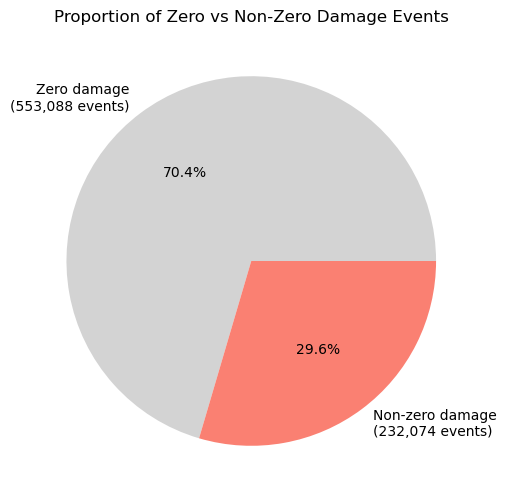

In [73]:
# Zero vs non-zero damage events

zero_damage = (df["damage"] == 0).sum()
non_zero_damage = (df["damage"] > 0).sum()

labels = [
    f"Zero damage\n({zero_damage:,} events)",
    f"Non-zero damage\n({non_zero_damage:,} events)"
]

sizes = [zero_damage, non_zero_damage]

# Gray for zero damage, red/orange for damaging events
colors = ["lightgray", "salmon"]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%"
)

plt.title("Proportion of Zero vs Non-Zero Damage Events")

plt.show()

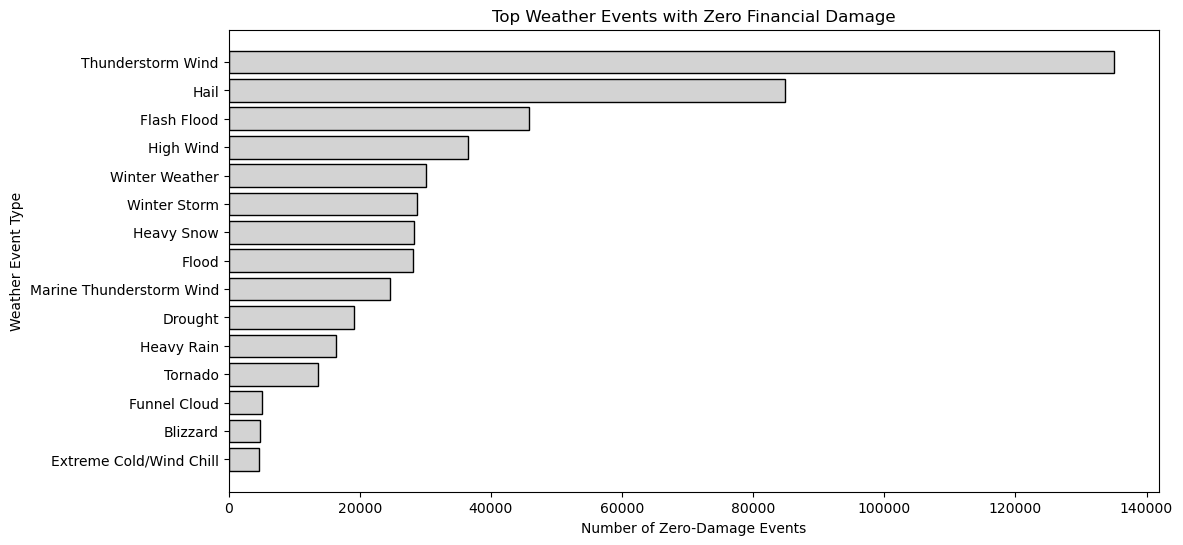

In [69]:
# Most common weather events with zero financial damage

zero_damage_events = (
    df[df["damage"] == 0]["event_type"]
    .value_counts()
    .head(15)
    .sort_values(ascending=True)
)

plt.figure(figsize=(12,6))

plt.barh(
    zero_damage_events.index,
    zero_damage_events.values,
    color="lightgray",
    edgecolor="black"
)

plt.title("Top Weather Events with Zero Financial Damage")
plt.xlabel("Number of Zero-Damage Events")
plt.ylabel("Weather Event Type")

plt.show()

In [14]:
# Remove zero-damage events

non_zero_damage = df[df["damage"] > 0]

print(non_zero_damage.shape)

(232074, 8)


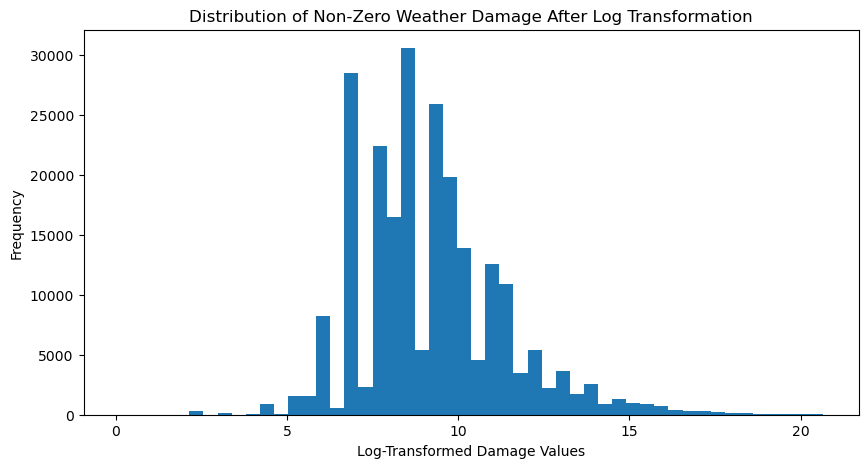

In [63]:
# Log-transformed non-zero damage distribution

plt.figure(figsize=(10,5))

plt.hist(np.log1p(non_zero_damage["damage"]), bins=50)

plt.title("Distribution of Non-Zero Weather Damage After Log Transformation")
plt.xlabel("Log-Transformed Damage Values")
plt.ylabel("Frequency")

plt.show()

**Interpretation of the Log-Transformed Damage Distribution**

The original damage distribution was heavily affected by extreme outliers and a large number of zero-damage events.  
After removing zero values and applying the logarithmic transformation using `log(1 + damage)`, the distribution became more balanced and easier to interpret.  
- Most weather events are associated with moderate levels of economic damage.  
- However, some severe events still cause exceptionally high financial losses, reflected by the remaining right-skewed tail of the distribution.  
- Overall, the transformed distribution highlights the considerable variability in the economic impact of severe weather events across the dataset.

### **Conclusion of Financial Damage Analysis**

The financial damage analysis shows that weather-related losses are highly unevenly distributed across events. Most recorded weather events cause little or no economic damage, while a relatively small number of extreme events generate exceptionally large losses.

The logarithmic transformation improved the interpretability of the damage distribution by reducing the influence of extreme outliers and revealing a more balanced pattern among non-zero damage values. Overall, the analysis confirms the presence of strong variability and right-skewness in economic damage caused by severe weather events.

### 2.2 Weather Event Frequency Analysis

This subsection explores the frequency and distribution of severe weather event types recorded in the dataset.


In [77]:
# Table of the most common weather events

top_events_table = (
    df["event_type"]
    .value_counts()
    .head(20)
    .reset_index()
)

# Rename columns
top_events_table.columns = ["Weather Event Type", "Number of Events"]

# Display table with title
print("Top 20 Most Frequent Weather Events")
display(top_events_table)

Top 20 Most Frequent Weather Events


,Weather Event Type,Number of Events
0,Thunderstorm Wind,268172
1,Hail,96930
2,Flash Flood,71018
3,High Wind,43401
4,Flood,38958
5,Winter Weather,31319
6,Winter Storm,30837
7,Heavy Snow,29224
8,Tornado,28283
9,Marine Thunderstorm Wind,24675


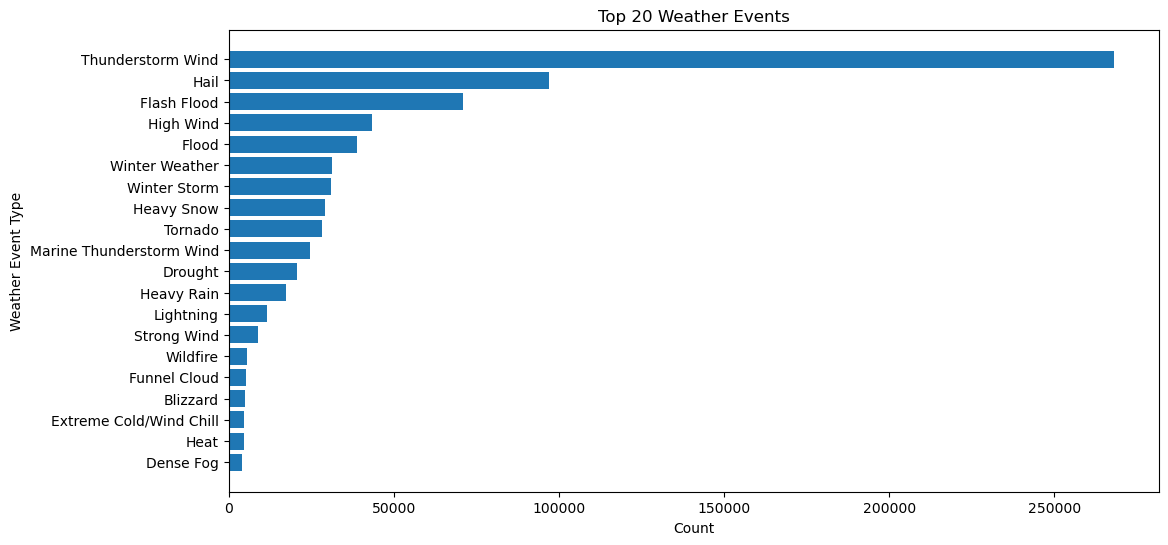

In [79]:
# Top 15 weather events

top_events = (
    df["event_type"]
    .value_counts()
    .head(20)
    .sort_values(ascending=True)
)

plt.figure(figsize=(12,6))

plt.barh(top_events.index, top_events.values)

plt.title("Top 20 Weather Events")
plt.xlabel("Count")
plt.ylabel("Weather Event Type")

plt.show()

**Interpretation of the Most Frequent Weather Events**

The analysis of event frequencies shows that **Thunderstorm Wind** is by far the most frequently recorded weather event in the dataset, followed by **Hail** and **Flash Flood** events.

These results describe how common each weather event type is, not how severe or economically damaging the events are. Therefore, highly frequent events are not necessarily the most destructive ones.

Other commonly reported events include:

- High Wind  
- Flood  
- Winter Weather  
- Winter Storm  
- Heavy Snow  

The results indicate that wind-related, precipitation-related, and winter-related hazards dominate severe weather reports across the United States.

In contrast, events such as **Wildfire**, **Strong Wind**, **Heat**, and **Dense Fog** occur less frequently within the top recorded categories.

Overall, the distribution demonstrates that weather hazards are not uniformly represented in the dataset, with a relatively small number of event types accounting for a large proportion of all severe weather reports. 

To better understand event severity, the next step is to analyse the average financial damage caused by each weather event type.

### **Conclusion of Weather Event Frequency Analysis**

The Weather Event Frequency Analysis shows that severe weather events are not equally represented within the dataset. Events such as **Thunderstorm Wind**, **Hail**, and **Flash Flood** occur far more frequently than other weather categories, indicating that wind- and precipitation-related hazards are the most commonly reported events.

However, the analysis also demonstrates that event frequency does not necessarily correspond to event severity. While some weather events occur very often, other less frequent events such as hurricanes, tropical storms, and tsunamis tend to produce substantially greater financial damage.

Overall, this subsection highlights the importance of analysing both the occurrence frequency and the economic impact of weather events in order to better understand the characteristics and risks associated with severe weather conditions.

### 2.3 Weather Events by Average Financial Damage

This subsection analyses the economic impact of severe weather events by examining the average financial damage associated with different event types and geographic regions. 

The analysis compares weather event frequency with average financial losses to identify which events and locations produce the greatest economic impact. 


- #### Average Financial Damage by Weather Event Type

In [81]:
# Top weather events by average financial damage

damage_by_event = (
    df.groupby("event_type")["damage"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

# Convert to table
damage_by_event_table = damage_by_event.reset_index()
damage_by_event_table.columns = [
    "Weather Event Type",
    "Average Financial Damage"
]

# Display table with title
print("Top 20 Weather Events by Average Financial Damage\n")
display(damage_by_event_table)

Top 20 Weather Events by Average Financial Damage



,Weather Event Type,Average Financial Damage
0,Hurricane (Typhoon),4.716546e+07
1,Storm Surge/Tide,7.809662e+06
2,Tsunami,4.468400e+06
3,Tropical Storm,2.763863e+06
4,Wildfire,1.320489e+06
5,Tornado,7.132574e+05
6,Debris Flow,6.866584e+05
7,Lakeshore Flood,5.551875e+05
8,Flood,5.527632e+05
9,Flash Flood,5.032404e+05


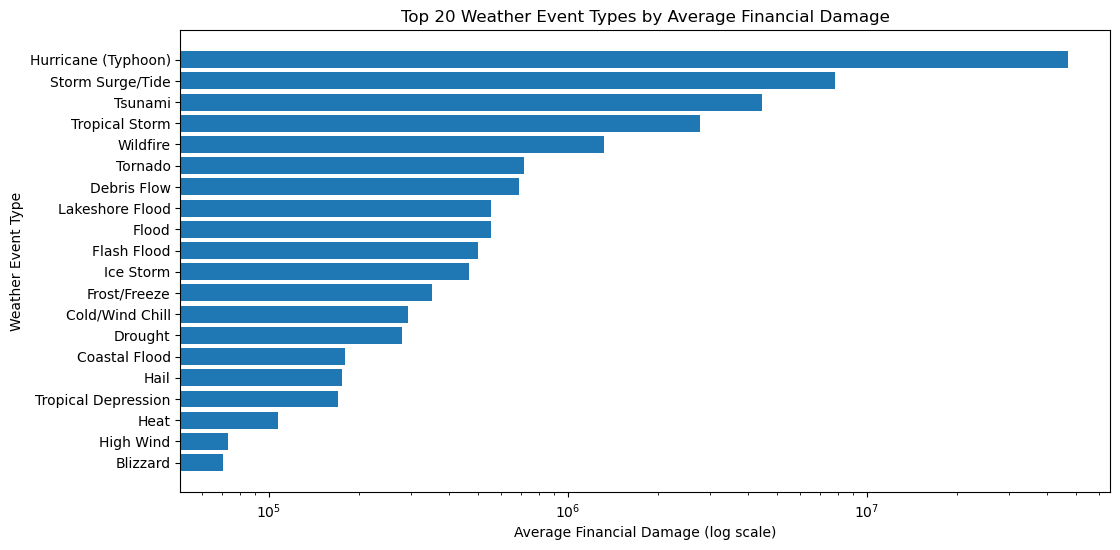

In [83]:
# Average financial damage by weather event type

damage_by_event = (
    df.groupby("event_type")["damage"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

# Plot top 20 weather event types by average financial damage

plt.figure(figsize=(12,6))

plt.barh(damage_by_event.index, damage_by_event.values)

plt.xscale("log")

plt.title("Top 20 Weather Event Types by Average Financial Damage")
plt.xlabel("Average Financial Damage (log scale)")
plt.ylabel("Weather Event Type")

plt.gca().invert_yaxis()

plt.show()

**Interpretation:**

The graph illustrates the average financial losses associated with different types of severe weather events. The results show that **Hurricane (Typhoon)** events cause by far the highest average economic damage compared to all other weather categories.

Other events with high average financial impacts include:

- Storm Surge/Tide  
- Tsunami  
- Tropical Storm  
- Wildfire  
- Tornado  

These types of events are typically associated with large-scale destruction, including damage to infrastructure, homes, transportation systems, agriculture, and coastal areas.

Although some events such as thunderstorms or hail occur more frequently in the dataset, they do not necessarily produce the highest financial losses. This demonstrates that event frequency and economic severity are not directly related.

The logarithmic scale was used to improve the readability of the visualization and to allow better comparisons between event categories with very different damage values.

Overall, the analysis highlights that a relatively small number of extreme weather events are responsible for the largest economic losses in the dataset.

- #### Average Financial Damage by State/Territory

In [43]:
# Number of unique states/territories
print("Total states/territories:", df["state"].nunique())

# Check unique state/territory names
sorted(df["state"].str.upper().unique())

Total states/territories: 70


['ALABAMA',
 'ALASKA',
 'AMERICAN SAMOA',
 'ARIZONA',
 'ARKANSAS',
 'ATLANTIC NORTH',
 'ATLANTIC SOUTH',
 'CALIFORNIA',
 'COLORADO',
 'CONNECTICUT',
 'DELAWARE',
 'DISTRICT OF COLUMBIA',
 'E PACIFIC',
 'FLORIDA',
 'GEORGIA',
 'GUAM',
 'GUAM WATERS',
 'GULF OF ALASKA',
 'GULF OF MEXICO',
 'HAWAII',
 'HAWAII WATERS',
 'IDAHO',
 'ILLINOIS',
 'INDIANA',
 'IOWA',
 'KANSAS',
 'KENTUCKY',
 'LAKE ERIE',
 'LAKE HURON',
 'LAKE MICHIGAN',
 'LAKE ONTARIO',
 'LAKE ST CLAIR',
 'LAKE SUPERIOR',
 'LOUISIANA',
 'MAINE',
 'MARYLAND',
 'MASSACHUSETTS',
 'MICHIGAN',
 'MINNESOTA',
 'MISSISSIPPI',
 'MISSOURI',
 'MONTANA',
 'NEBRASKA',
 'NEVADA',
 'NEW HAMPSHIRE',
 'NEW JERSEY',
 'NEW MEXICO',
 'NEW YORK',
 'NORTH CAROLINA',
 'NORTH DAKOTA',
 'OHIO',
 'OKLAHOMA',
 'OREGON',
 'PENNSYLVANIA',
 'PUERTO RICO',
 'RHODE ISLAND',
 'SOUTH CAROLINA',
 'SOUTH DAKOTA',
 'ST LAWRENCE R',
 'TENNESSEE',
 'TEXAS',
 'UNKNOWN',
 'UTAH',
 'VERMONT',
 'VIRGIN ISLANDS',
 'VIRGINIA',
 'WASHINGTON',
 'WEST VIRGINIA',
 'WISCONSIN'

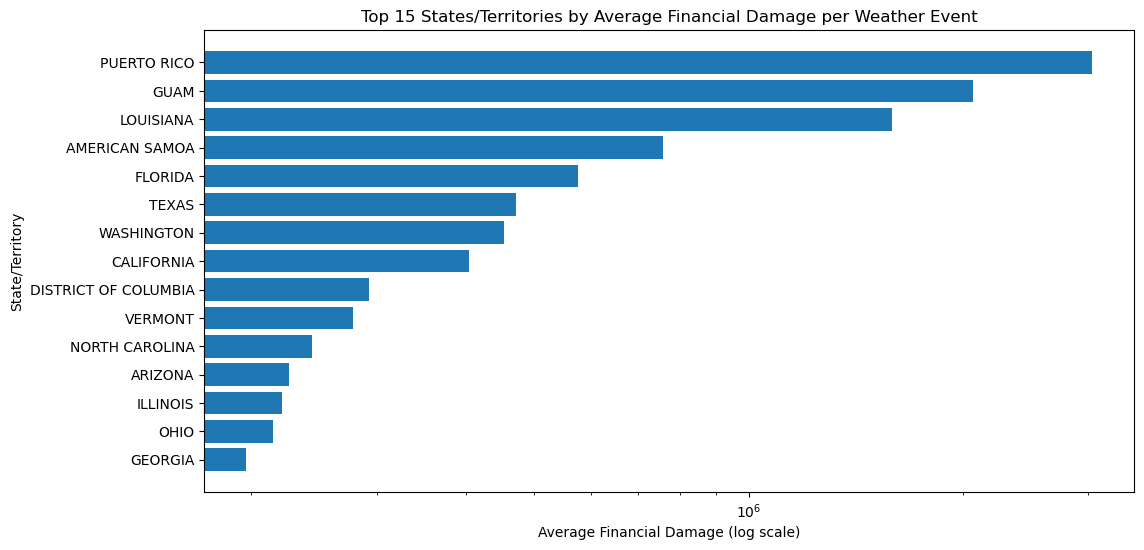

In [55]:
# Average financial damage by state/territory

damage_by_state = (
    df.groupby("state")["damage"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

# Plot average financial damage by state/territory

plt.figure(figsize=(12,6))

plt.barh(damage_by_state.index, damage_by_state.values)

plt.xscale("log")

plt.title("Top 15 States/Territories by Average Financial Damage per Weather Event")
plt.xlabel("Average Financial Damage (log scale)")
plt.ylabel("State/Territory")

plt.gca().invert_yaxis()

plt.show()

**Interpretation:**

The graph shows the average financial loss caused by weather events in different U.S. states and territories.
- Puerto Rico, Guam, and Louisiana record the highest average damages, meaning that a single weather event in these regions tends to produce larger economic losses compared to other areas.
- This is likely related to severe events such as hurricanes, tropical storms, and coastal flooding, which can cause extensive infrastructure and property damage.

Overall, the analysis suggests that coastal and tropical regions are more vulnerable to high-cost weather disasters.

- #### Comparison Between Event Frequency and Financial Damage

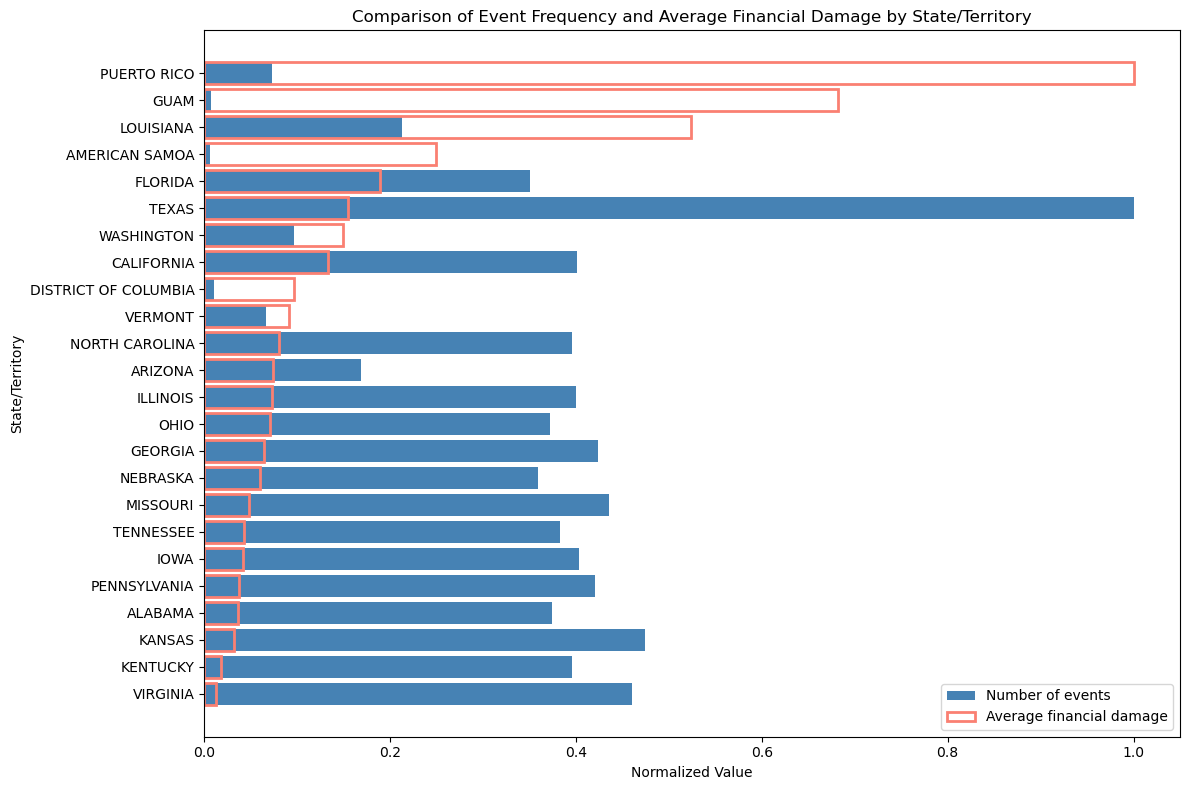

In [59]:
# Compare event frequency and average financial damage by state/territory

plt.figure(figsize=(12,8))

# Filled blue bars for number of events
plt.barh(
    comparison.index,
    comparison["events_normalized"],
    color="steelblue",
    label="Number of events"
)

# Transparent red outlined bars for average damage
plt.barh(
    comparison.index,
    comparison["damage_normalized"],
    facecolor="none",
    edgecolor="salmon",
    linewidth=2,
    label="Average financial damage"
)

plt.title("Comparison of Event Frequency and Average Financial Damage by State/Territory")
plt.xlabel("Normalized Value")
plt.ylabel("State/Territory")

plt.legend()

plt.tight_layout()

plt.show()

Interpretation:

The comparison between the number of weather events and the average financial damage shows that:

- Texas records the highest number of severe weather events.
- States with many weather events do not always experience the highest financial losses.
- Puerto Rico and Guam have fewer events overall, but much higher average financial damage per event.
- Louisiana also shows high economic losses compared to its event frequency.
- Some regions are affected by frequent but less severe events, while others experience fewer but much more destructive disasters.

## 3. NLP and Text Analysis

Now that the exploratory data analysis (EDA) is complete, the next step is to analyze the textual weather narratives using Natural Language Processing (NLP).

The goal of this section is to:

preprocess the weather narratives,
extract important words and patterns,
identify commonly used terms in severe weather descriptions,
and explore how language relates to weather damage.

In [27]:
# Combine both narrative columns into one text column

df["full_text"] = df["episode_narrative"] + " " + df["event_narrative"]

# Preview combined text

df[["full_text"]].head()

,full_text
0,Tropical Storm Lee formed from a persistent lo...
1,Scattered thunderstorms moved across portions ...
2,"During the evening hours on July 19th, a sever..."
3,An upper-level trough moved through southern C...
4,A small cluster of thunderstorms developed nor...


### 3.1 Text Length Analysis

In [22]:
# Calculate text length

df["text_length"] = df["full_text"].apply(len)

# Summary statistics

df["text_length"].describe()

count    785162.000000
mean        587.239013
std         816.020737
min           2.000000
25%         226.000000
50%         389.000000
75%         685.000000
max       41227.000000
Name: text_length, dtype: float64

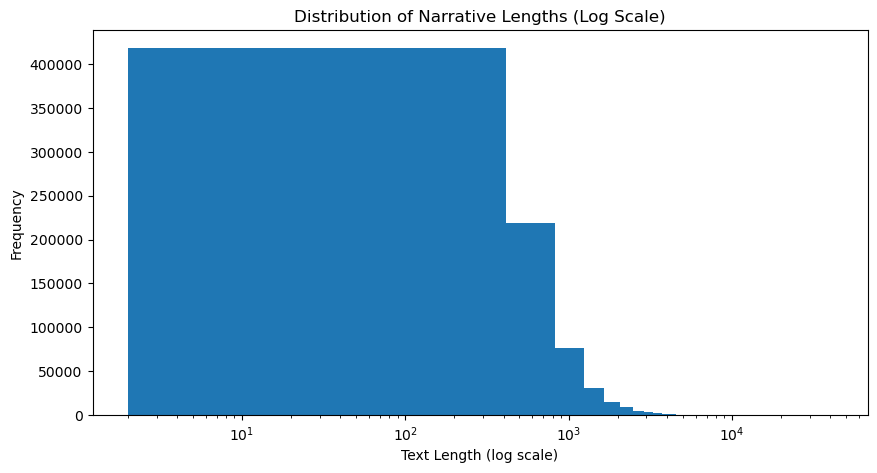

In [25]:
# Plot text length distribution (log scale)

plt.figure(figsize=(10,5))

plt.hist(df["text_length"], bins=100)

plt.xscale("log")

plt.title("Distribution of Narrative Lengths (Log Scale)")
plt.xlabel("Text Length (log scale)")
plt.ylabel("Frequency")

plt.show()

**Interpretation of Narrative Length Distribution**

The graph shows that most weather reports are short and contain only basic information about the event. However, a smaller number of reports are much longer because they describe more serious or complex situations in greater detail.

In practice, this means that severe weather events such as hurricanes, floods, or large storms usually require longer explanations from meteorologists, while smaller events can be described in only a few sentences.

The logarithmic scale helps display both short and very long reports more clearly on the same graph.

### 3.2 Text Cleaning and Normalization

In [34]:
# Text cleaning and normalization

import re                                                           # Import regular expressions library
from nltk.corpus import stopwords                                   # Import stopwords (common words like "the", "and", etc.)
from nltk.tokenize import word_tokenize                             # Import tokenizer (splits text into words)

stop_words = set(stopwords.words("english"))                        # Create a set of English stopwords

# Function to clean text
def clean_text(text):
    text = text.lower()                                             # Convert text to lowercase
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)                      # Remove punctuation but keep numbers
    tokens = word_tokenize(text)                                    # Split text into individual words
    tokens = [word for word in tokens if word not in stop_words]    # Remove stopwords
    return " ".join(tokens)                                         # Join cleaned words back into text

# Apply preprocessing to narratives
df["clean_text"] = df["full_text"].apply(clean_text)

# Compare original and cleaned text
df[["full_text", "clean_text"]].head()

,full_text,clean_text
0,Tropical Storm Lee formed from a persistent lo...,tropical storm lee formed persistent low press...
1,Scattered thunderstorms moved across portions ...,scattered thunderstorms moved across portions ...
2,"During the evening hours on July 19th, a sever...",evening hours july 19th severe thunderstorm br...
3,An upper-level trough moved through southern C...,upperlevel trough moved southern california st...
4,A small cluster of thunderstorms developed nor...,small cluster thunderstorms developed north wa...


### 3.3 Most Common Words Analysis

In [36]:
# Word frequency analysis

from collections import Counter                         # Import Counter for word frequency counting


# Combine all cleaned text into one large text
all_words = " ".join(df["clean_text"])

# Split text into words
tokens = all_words.split()

# Count word frequencies
word_freq = Counter(tokens)

# Convert top 15 words into dataframe
common_words = pd.DataFrame(
    word_freq.most_common(15),
    columns=["word", "frequency"]
)

# Display most common words
common_words

,word,frequency
0,across,728484
1,county,574466
2,inches,478427
3,winds,435391
4,wind,429099
5,thunderstorms,415867
6,reported,364758
7,damage,351218
8,snow,344199
9,severe,342292


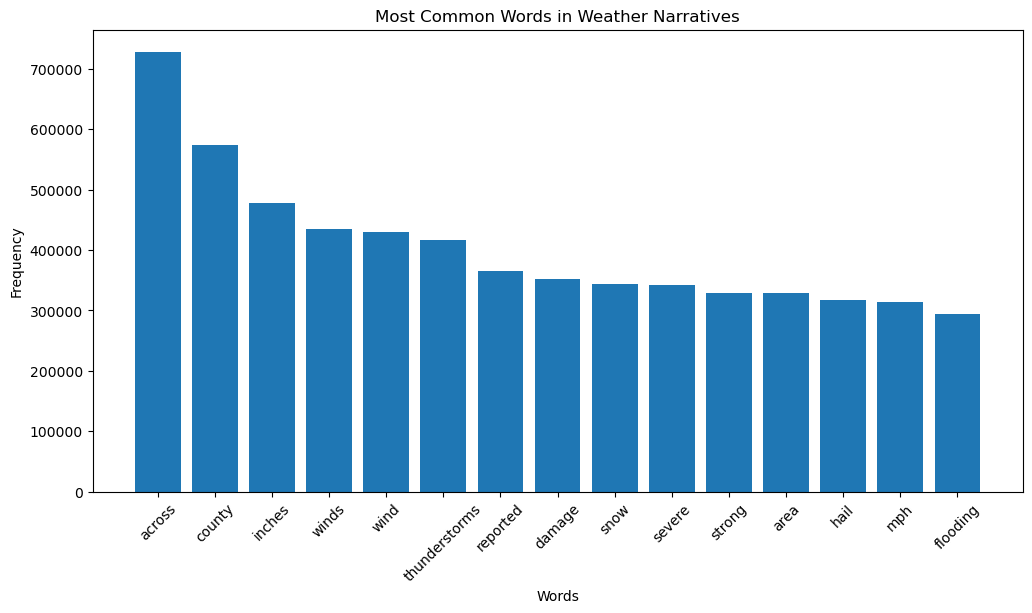

In [37]:
# Plot most common words
plt.figure(figsize=(12,6))

plt.bar(common_words["word"], common_words["frequency"])

plt.title("Most Common Words in Weather Narratives")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

**Interpretation of the Most Common Words**

The most common words are strongly related to weather reports and storm impacts. Terms such as "winds", "thunderstorms", "damage", "hail", and "flooding" appear very frequently, showing that the narratives mainly describe severe weather conditions and their consequences.

Words like "inches" and "mph" also appear often, indicating that many reports include numerical measurements such as rainfall amounts and wind speeds. This confirms that the text contains useful information for further NLP and machine learning analysis.